In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/raw/bank.csv", sep=';')

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [6]:
df.shape

(4521, 17)

In [7]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [8]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

In [9]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [10]:
df.describe(include="object")

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,4521,4521,4521,4521,4521,4521,4521,4521,4521,4521
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,yes,no,cellular,may,unknown,no
freq,969,2797,2306,4445,2559,3830,2896,1398,3705,4000


In [13]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [14]:
df.duplicated().sum()

0

In [15]:
df["y"].value_counts()

y
no     4000
yes     521
Name: count, dtype: int64

In [16]:
df["y"].value_counts(normalize=True) * 100

y
no     88.476001
yes    11.523999
Name: proportion, dtype: float64

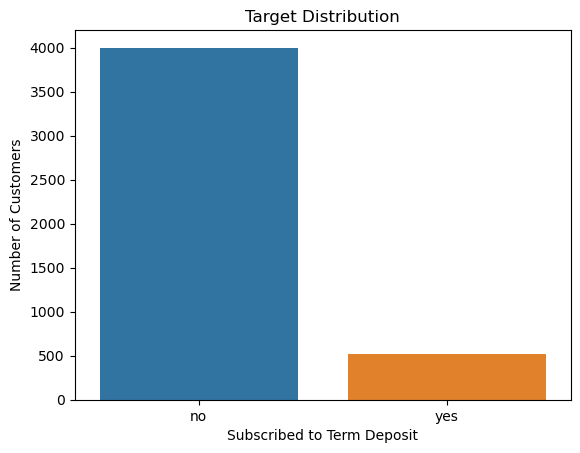

In [17]:
sns.countplot(data=df, x="y")

plt.title("Target Distribution")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Number of Customers")

plt.show()

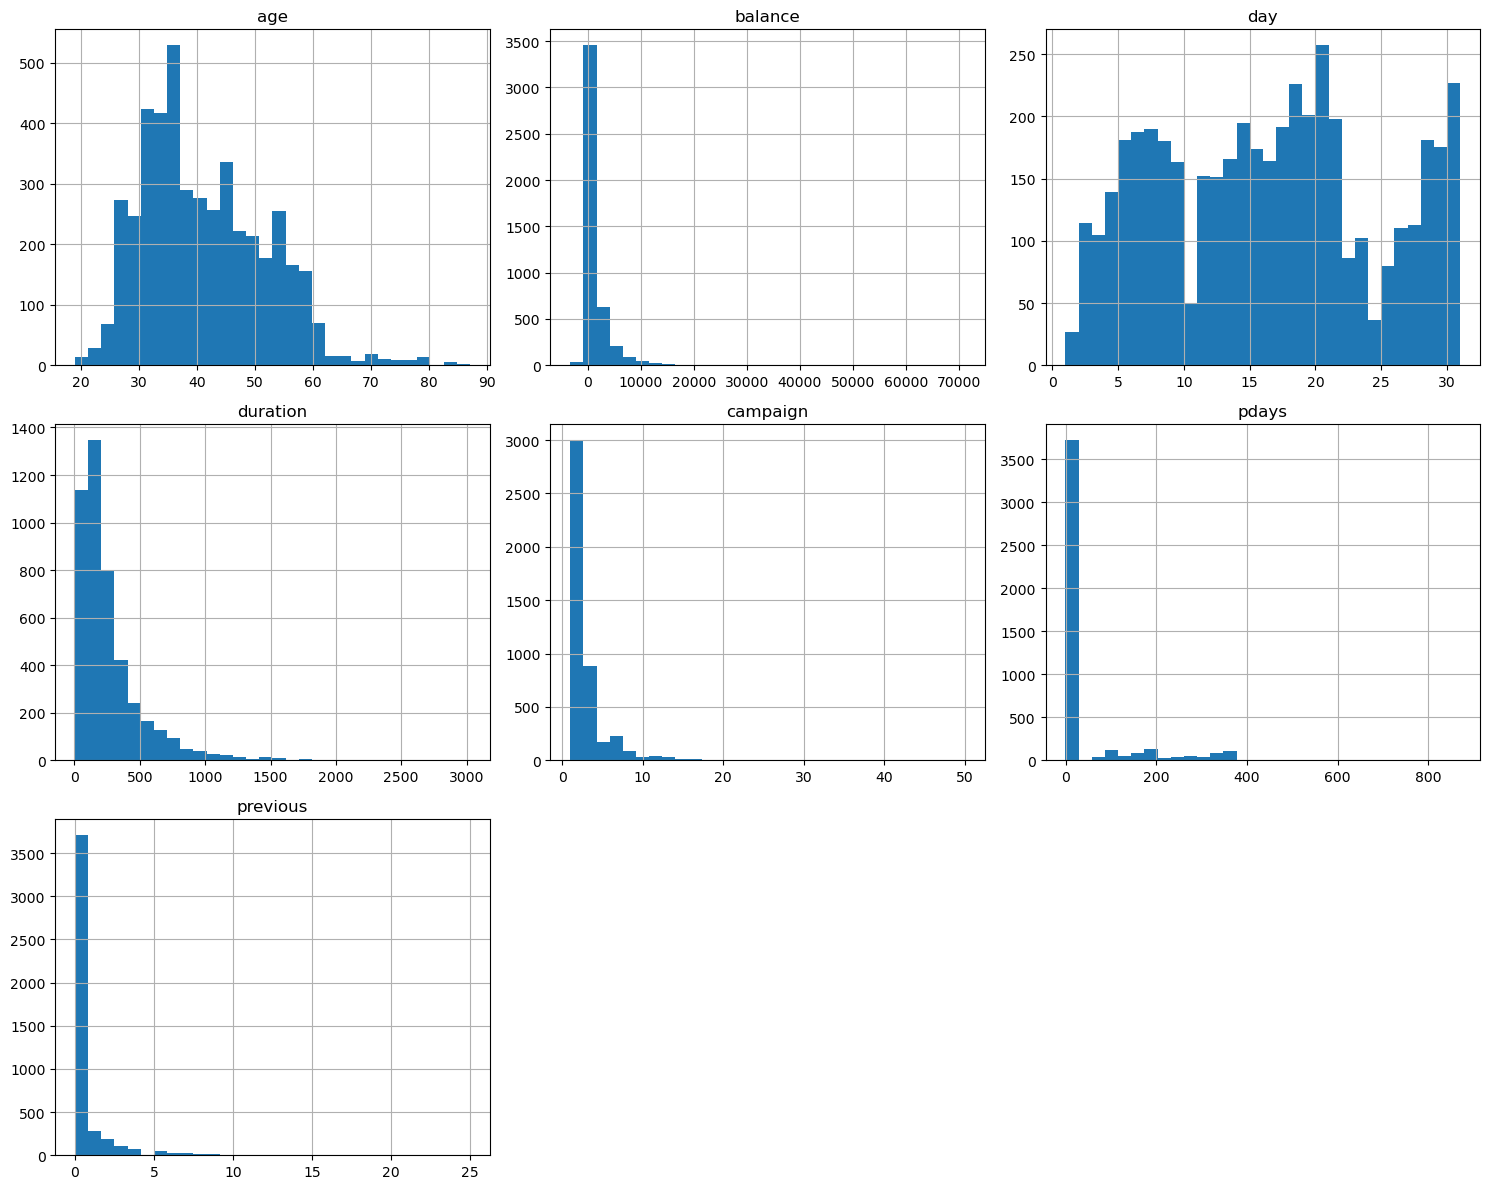

In [18]:
df.hist(figsize=(15, 12), bins=30)

plt.tight_layout()
plt.show()

In [19]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nTarget distribution:")
print(df["y"].value_counts())

print("\nTarget percentage:")
print(df["y"].value_counts(normalize=True) * 100)

Dataset shape: (4521, 17)

Missing values:
0

Duplicate rows:
0

Target distribution:
y
no     4000
yes     521
Name: count, dtype: int64

Target percentage:
y
no     88.476001
yes    11.523999
Name: proportion, dtype: float64


In [20]:
job_subscription = (
    df.groupby("job")["y"]
      .apply(lambda x: (x == "yes").mean() * 100)
      .sort_values(ascending=False)
)

job_subscription

job
retired          23.478261
student          22.619048
unknown          18.421053
management       13.519092
housemaid        12.500000
admin.           12.133891
self-employed    10.928962
technician       10.807292
unemployed       10.156250
services          9.112710
entrepreneur      8.928571
blue-collar       7.293869
Name: y, dtype: float64

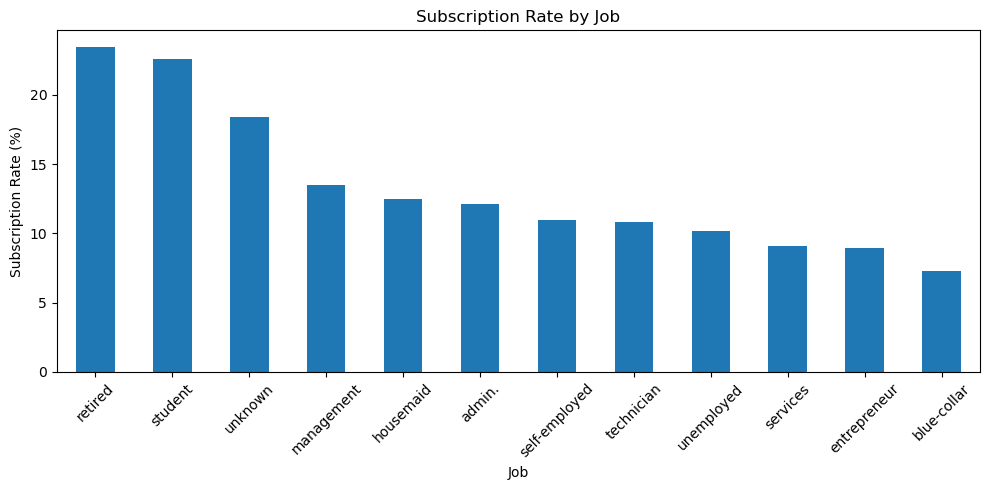

In [21]:
job_subscription.plot(kind="bar", figsize=(10, 5))

plt.title("Subscription Rate by Job")
plt.xlabel("Job")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()